In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from scipy import stats
from sklearn.dummy import DummyClassifier

In [8]:
filename = 'phishing_websites.csv'
dataset = pd.read_csv(filename).to_numpy()
dataset = np.array(dataset, dtype=np.float32)
X = dataset[:,0:30]
y = dataset[:,-1]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(np.shape(X_train))
print(np.shape(X_test))

(8843, 30)
(2211, 30)


In [10]:
lin_reg = LogisticRegression()
lin_reg.fit(X_train, y_train)
lin_reg.intercept_, lin_reg.coef_

(array([2.595253]),
 array([[ 0.65030931, -0.16839992, -0.8075023 ,  0.31763241,  0.17764343,
          2.77462024,  0.58798526,  1.5951161 ,  0.04894514, -0.29756331,
          0.47389977, -0.44569472,  0.27002927,  3.11988128,  0.76024416,
          0.89240921, -0.3127124 , -0.16724832, -1.20775357,  0.18865101,
          0.05220696, -0.04579951, -0.21665937,  0.08043894,  0.49741258,
          0.74817308,  0.16648209,  0.68975169,  0.80336286,  0.30425161]]))

In [11]:
y_pred = lin_reg.predict(X_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
fscore = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F-Score: {fscore:.4f}")

Precision: 0.9297
Recall: 0.9530
F-Score: 0.9412


In [13]:
y_scores = lin_reg.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

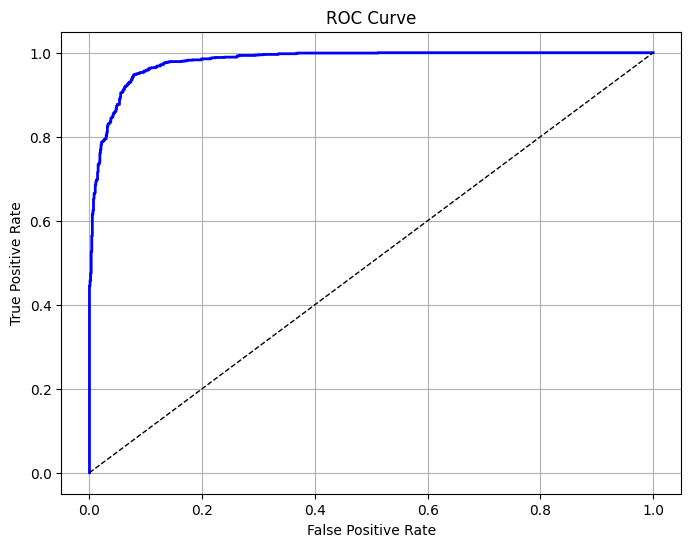

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid(True)
plt.show()

In [15]:
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

AUC: 0.9804


In [16]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

lr_scores = []
dummy_scores = []

for train_idx, test_idx in cv.split(X_train, y_train):
    X_tr, X_te = X_train[train_idx], X_train[test_idx]
    y_tr, y_te = y_train[train_idx], y_train[test_idx]
    
    lr = LogisticRegression()
    lr.fit(X_tr, y_tr)
    lr_scores.append(lr.score(X_te, y_te))
    
    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(X_tr, y_tr)
    dummy_scores.append(dummy.score(X_te, y_te))

In [17]:
statistic, p_value = stats.wilcoxon(lr_scores, dummy_scores)
print(f"Wilcoxon p-value: {p_value:.4f}")

Wilcoxon p-value: 0.0020
